In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# **Function 1** - Searching for Contamination Sources


For this function we must detect likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading.

- The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

**Input** - 2D array (10,2)
**Output** - 1D array (10,)

- **Optimisation Goal** - Maximise

I want to begin this week's analysis by loading the data and appending new week's data to the initial data.


In [ ]:
X = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_1\initial_inputs.npy')
Y = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_1\initial_outputs.npy')

In [ ]:
import numpy as np

# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.996651, 0.001439], dtype=np.float64)
Y_w1_new_point = np.array([0], dtype=np.float64)

# Append the new data point (ensure it's a 2D row)
X_updated = np.vstack((X, X_w1_new_point.reshape(1, -1)))

# Remove duplicate rows and align outputs with the deduplicated inputs
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)
sorted_idx = np.sort(unique_indices)
X_unique = X_updated[sorted_idx]

Y_all = np.append(Y, Y_w1_new_point)
Y_updated = Y_all[sorted_idx]

# Save the updated arrays
np.save(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_1\initial_inputs.npy', X_unique)
np.save(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_1\initial_outputs.npy', Y_updated)

In [6]:
# Show updated arrays
print("Updated Inputs (X) - Function 1: ", X_unique)
print("Updated Outputs (Y) - Function 1: ", Y_updated)

Updated Inputs (X) - Function 1:  [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.996651   0.001439  ]]
Updated Outputs (Y) - Function 1:  [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  0.00000000e+000]


### **Interpreation of the Output and Potential Next steps to improve the model**


Since we are working with a contaminiation detection problem, we can assume a very low noise level in the observations.

The first output that we have is 0.0, meaning that the current search querey is out of range. In the radiation field, a zero reading means that my chosen coordinates are not yet close enough to detect a signal.

Since this was based on a random search, I am planning to switch to a more strategic approach using Gaussian Processes and create a surrogate function to create a query which is informed based on the model that we have created.

- For this particular function I want to use the Matern kerenl and starting with a Expected Improvement surrogate model which can help guide the query for this week.


### **Bayesian Optimisation** - Guassian Processes


- I am making 2 changes to this approach and use the more strategic approach in order to get a more analytical output.
  - I want to make `the noise_assumption = 1e-10` to ensure that the model isn't guessing where we have already proven that there isn't a signal present.

  - I want to change this to a more critical `Matern` kernel.
    - Additioanlly, when looking deeper into this I realised that Matern 1.5 is often used for rougher surfaces like radiation spikes.

  - I have also added `n_restarts_optimizer` = 10 to ensure that the entire landscape of the data is covered.


In [9]:
kernel = Matern(
    length_scale = 0.1,
    length_scale_bounds = 'fixed',
    nu = 1.5,
)

model = GaussianProcessRegressor(
    kernel = kernel,
    alpha = 1e-10,
    n_restarts_optimizer= 10,
    normalize_y = True,
)

model.fit(X_unique, Y_updated)

GaussianProcessRegressor(kernel=Matern(length_scale=0.1, nu=1.5),
                         n_restarts_optimizer=10, normalize_y=True)

### **Acquisition Function** - Expected Improvement (EI)

- I have decided to expected improvement so that I can find areas of improvement and get a next query which explores a different space from ones which I have laready looked at.
- Additionally, I used `x_linspace`, where I used `np.inspace(0, 1, 100)` to split the inputt range [0, 1] into 100 equal steps.
  - Then I used this to create a `np.meshgrid` to cross the 100 steps into 10,000 unique points which cover the entire 2D surface.
  - Finally, I reformated (using `reshape (-1, 2)`) the grid into a list of (x, y) coordinates so that the Guassian Model can understand the values better.


In [12]:
def expected_improvement(X_grid, model, y_max, xi=0.01):
    mu, sigma = model.predict(X_grid, return_std=True)
    mu, sigma = mu.reshape(-1, 1), sigma.reshape(-1, 1)
    
    with np.errstate(divide='ignore'):
        imp = mu - y_max - xi
        Z = imp / (sigma + 1e-9)
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0
    return ei.ravel()

x_linspace = np.linspace(0, 1, 100)
x_grid = np.array(np.meshgrid(x_linspace, x_linspace)).T.reshape(-1, 2)

y_max = np.max(Y_updated)
ei_values = expected_improvement(x_grid, model, y_max)

next_query = x_grid[np.argmax(ei_values)]
print(f"Strategic Week 2 Query (Function 1): {next_query[0]:.6f}-{next_query[1]:.6f}")

Strategic Week 2 Query (Function 1): 0.919192-0.838384


### **Visualisation of the Model**


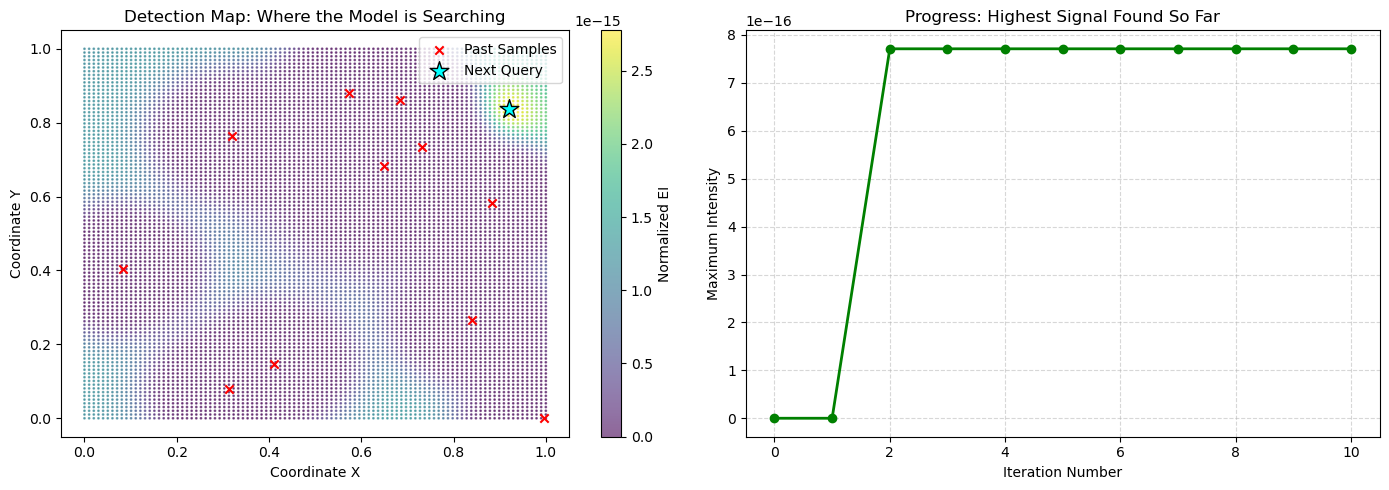

Strategic Result: Next point to query is at (0.919192-0.838384)


In [11]:
# Calculate running maximum of observed values for progress plot
running_max = np.maximum.accumulate(Y_updated)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Define the acquisition function used for plotting.
acquisition_function = ei_values
acq_norm = (acquisition_function - np.nanmin(acquisition_function)) / (np.nanmax(acquisition_function) - np.nanmin(acquisition_function) + 1e-12)

# The Search Map (Where are we looking?)
# This shows the "hot zones" the model wants to explore next.
sc = ax1.scatter(x_grid[:, 0], x_grid[:, 1], c=acq_norm, cmap='viridis', s=1, alpha=0.6)
cbar = plt.colorbar(sc, ax=ax1, label='Normalized EI')
ax1.scatter(X_unique[:, 0], X_unique[:, 1], c='red', marker='x', label='Past Samples')
ax1.scatter(next_query[0], next_query[1], c='cyan', marker='*', s=200, edgecolors='black', label='Next Query')
ax1.set_title('Detection Map: Where the Model is Searching')
ax1.set_xlabel('Coordinate X')
ax1.set_ylabel('Coordinate Y')
ax1.legend()

# The Progress Plot (Are we finding anything?)
# A simple line graph showing the best detection score over time.
ax2.plot(running_max, color='green', linewidth=2, marker='o')
ax2.set_title('Progress: Highest Signal Found So Far')
ax2.set_xlabel('Iteration Number')
ax2.set_ylabel('Maximum Intensity')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Strategic Result: Next point to query is at ({next_query[0]:.6f}-{next_query[1]:.6f})")